# **🐍 Lab 01: Python Fundamentals & Virtual Environment Setup (In-Class)**

#### **Made by SSJin (2026.03.07)**
#### Sejong University, Dept. of Civil & Environmental Engineering

---

## **📋 Learning Objectives**

Upon completing this lab, you will be able to:

1. **Create** three separate conda virtual environments and **explain** why isolation matters.
2. **Demonstrate** that missing packages in one environment cause import errors, while another environment works correctly.
3. **Identify** and use Python's core data types, operators, and control structures.
4. **Write** functions to solve basic civil and environmental engineering calculations.
5. **Apply** lists, dictionaries, and loops to process engineering datasets.

---

> **📌 Instructions**: Fill in the blanks (`________`) in cells marked with `[EXERCISE]`.  
> Answer keys are provided in the **Answer Key** section at the bottom.

---
# **Part 1: Virtual Environment Setup & Dependency Conflicts**

## **1.1 Why Virtual Environments?**

In real engineering projects, different tasks require different library versions:

| Project | Python | Key Libraries |
|---------|--------|---------------|
| Data Analysis | 3.9 | NumPy, Pandas, Matplotlib, scikit-learn |
| Deep Learning | 3.9 | PyTorch/TensorFlow, CUDA-specific packages |
| Web Dashboard | 3.10 | Flask, Plotly, SQLAlchemy |

Without virtual environments, installing packages for one project can **break** another project. This is called **"Dependency Hell"**.

> **🔑 Key Concept**: A virtual environment is an isolated Python installation. Each environment has its own Python version and its own set of installed packages. Changes in one environment do **not** affect others.

---

## **1.2 Hands-On: Creating Three Environments**

Open the **VS Code Integrated Terminal** (`Ctrl+\``) or **Anaconda Prompt** and execute the following commands **in order**.

We will create three environments:

| Environment | Purpose | Packages |
|-------------|---------|----------|
| `env_full` | Full data science stack | NumPy, Pandas, Matplotlib, scikit-learn, Jupyter, ipykernel |
| `env_minimal` | Bare Python only | *(no scientific packages)* |
| `env_viz` | Visualization only | Matplotlib, ipykernel *(no NumPy explicitly, no Pandas)* |

### **Step 1: Create `env_full` (Full Data Science Stack)**

```bash
conda create -n env_full python=3.9 -y
conda activate env_full
conda install numpy pandas matplotlib scikit-learn jupyter ipykernel -y
conda deactivate
```

### **Step 2: Create `env_minimal` (Bare Python — No Scientific Packages)**

```bash
conda create -n env_minimal python=3.9 -y
conda activate env_minimal
conda install ipykernel -y
conda deactivate
```

### **Step 3: Create `env_viz` (Matplotlib Only — No Pandas)**

```bash
conda create -n env_viz python=3.9 -y
conda activate env_viz
conda install matplotlib ipykernel -y
conda deactivate
```

### **Step 4: Verify All Three Environments Exist**

```bash
conda env list
```

You should see `env_full`, `env_minimal`, and `env_viz` in the list.

> **⏳ Note**: Creating environments takes a few minutes. While waiting, read ahead to understand what we will test.

## **1.3 Experiment A: Select `env_full` Kernel — Everything Works**

**Change your Notebook kernel to `env_full`**:  
Click the kernel button (top-right) → Python Environments → `env_full (conda)`

Then run the cell below. All imports should succeed.

In [3]:
# === Experiment A: env_full — Full Stack Test ===
# Expected: ALL imports succeed

import sys, os
print(f'Python: {sys.version}')
print(f'Environment: {os.environ.get("CONDA_DEFAULT_ENV", "unknown")}')
print()

try:
    import numpy as np
    print(f'✅ NumPy {np.__version__} — imported successfully')
except ImportError:
    print('❌ NumPy — NOT FOUND')

try:
    import pandas as pd
    print(f'✅ Pandas {pd.__version__} — imported successfully')
except ImportError:
    print('❌ Pandas — NOT FOUND')

try:
    import matplotlib
    print(f'✅ Matplotlib {matplotlib.__version__} — imported successfully')
except ImportError:
    print('❌ Matplotlib — NOT FOUND')

try:
    import sklearn
    print(f'✅ scikit-learn {sklearn.__version__} — imported successfully')
except ImportError:
    print('❌ scikit-learn — NOT FOUND')

Python: 3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
Environment: env_full

✅ NumPy 1.26.4 — imported successfully
✅ Pandas 2.3.3 — imported successfully
✅ Matplotlib 3.9.2 — imported successfully
✅ scikit-learn 1.5.1 — imported successfully


## **1.4 Experiment B: Switch to `env_minimal` Kernel — Import Failures**

**Change your Notebook kernel to `env_minimal`**:  
Click the kernel button (top-right) → Python Environments → `env_minimal (conda)`

Run the **same** cell below. You should see **all imports fail** because `env_minimal` has no scientific packages.

In [1]:
# === Experiment B: env_minimal — Bare Python Test ===
# Expected: ALL scientific imports FAIL

import sys, os
print(f'Python: {sys.version}')
print(f'Environment: {os.environ.get("CONDA_DEFAULT_ENV", "unknown")}')
print()

try:
    import numpy as np
    print(f'✅ NumPy {np.__version__} — imported successfully')
except ImportError:
    print('❌ NumPy — NOT FOUND (ModuleNotFoundError)')

try:
    import pandas as pd
    print(f'✅ Pandas {pd.__version__} — imported successfully')
except ImportError:
    print('❌ Pandas — NOT FOUND (ModuleNotFoundError)')

try:
    import matplotlib
    print(f'✅ Matplotlib {matplotlib.__version__} — imported successfully')
except ImportError:
    print('❌ Matplotlib — NOT FOUND (ModuleNotFoundError)')

try:
    import sklearn
    print(f'✅ scikit-learn {sklearn.__version__} — imported successfully')
except ImportError:
    print('❌ scikit-learn — NOT FOUND (ModuleNotFoundError)')

print()
print('💡 Lesson: This environment has only bare Python.')
print('   Scientific packages must be installed separately in each environment.')

Python: 3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
Environment: env_minimal

❌ NumPy — NOT FOUND (ModuleNotFoundError)
❌ Pandas — NOT FOUND (ModuleNotFoundError)
❌ Matplotlib — NOT FOUND (ModuleNotFoundError)
❌ scikit-learn — NOT FOUND (ModuleNotFoundError)

💡 Lesson: This environment has only bare Python.
   Scientific packages must be installed separately in each environment.


## **1.5 Experiment C: Switch to `env_viz` Kernel — Partial Availability**

**Change your Notebook kernel to `env_viz`**:  
Click the kernel button (top-right) → Python Environments → `env_viz (conda)`

Run the cell below. Matplotlib should work (and NumPy, since Matplotlib depends on it), but **Pandas and scikit-learn will fail**.

In [1]:
# === Experiment C: env_viz — Partial Stack Test ===
# Expected: NumPy & Matplotlib succeed, Pandas & scikit-learn FAIL

import sys, os
print(f'Python: {sys.version}')
print(f'Environment: {os.environ.get("CONDA_DEFAULT_ENV", "unknown")}')
print()

try:
    import numpy as np
    print(f'✅ NumPy {np.__version__} — imported (installed as Matplotlib dependency)')
except ImportError:
    print('❌ NumPy — NOT FOUND')

try:
    import pandas as pd
    print(f'✅ Pandas {pd.__version__} — imported successfully')
except ImportError:
    print('❌ Pandas — NOT FOUND (not installed in env_viz)')

try:
    import matplotlib
    print(f'✅ Matplotlib {matplotlib.__version__} — imported successfully')
except ImportError:
    print('❌ Matplotlib — NOT FOUND')

try:
    import sklearn
    print(f'✅ scikit-learn {sklearn.__version__} — imported successfully')
except ImportError:
    print('❌ scikit-learn — NOT FOUND (not installed in env_viz)')

print()
print('💡 Lesson: env_viz has Matplotlib (and NumPy as its dependency),')
print('   but Pandas and scikit-learn were never installed here.')

Python: 3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
Environment: env_viz

✅ NumPy 2.0.1 — imported (installed as Matplotlib dependency)
❌ Pandas — NOT FOUND (not installed in env_viz)
✅ Matplotlib 3.9.2 — imported successfully
❌ scikit-learn — NOT FOUND (not installed in env_viz)

💡 Lesson: env_viz has Matplotlib (and NumPy as its dependency),
   but Pandas and scikit-learn were never installed here.


## **1.6 Experiment D: Prove the Conflict — Code That Breaks in Wrong Environment**

The following code performs a typical data analysis workflow:  
1. Create data with NumPy  
2. Store in a Pandas DataFrame  
3. Plot with Matplotlib  

**Try running it in all three environments** and observe which environments succeed and which fail.

| Environment | Expected Result |
|-------------|-----------------|
| `env_full` | ✅ Runs completely — graph displayed |
| `env_minimal` | ❌ Fails at `import numpy` (line 1) |
| `env_viz` | ❌ Fails at `import pandas` (line 2) |

 Curing Days  Strength (MPa)
           1             6.2
           3            13.7
           7            21.1
          14            26.4
          28            30.2
          56            32.6
          90            33.5


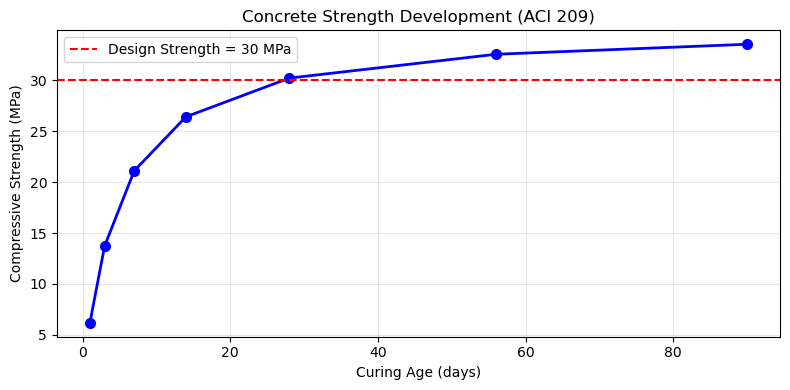


✅ Full workflow completed successfully!


In [1]:
# === Experiment D: Full Workflow — Only works in env_full ===
# Switch kernels and observe where it breaks!

import numpy as np                    # Fails in env_minimal
import pandas as pd                   # Fails in env_viz
import matplotlib.pyplot as plt

# Generate concrete curing data
days = np.array([1, 3, 7, 14, 28, 56, 90])
fck_28 = 30  # 28-day design strength [MPa]
strength = days / (4.0 + 0.85 * days) * fck_28  # ACI 209 model

# Create DataFrame
df = pd.DataFrame({'Curing Days': days, 'Strength (MPa)': np.round(strength, 1)})
print(df.to_string(index=False))

# Plot
plt.figure(figsize=(8, 4))
plt.plot(days, strength, 'bo-', linewidth=2, markersize=7)
plt.axhline(y=fck_28, color='r', linestyle='--', label=f'Design Strength = {fck_28} MPa')
plt.xlabel('Curing Age (days)')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Concrete Strength Development (ACI 209)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n✅ Full workflow completed successfully!')

## 1.7 **[EXERCISE] Environment Reflection Questions**

Answer the following questions in the Markdown cell below (double-click to edit):

> 1. Why did `import numpy` succeed in `env_viz` even though we only installed Matplotlib?

**Your Answers:**

because if I install matplotlib, matplotlib depend on numpy, pillow etc.

> 2. If you need to add Pandas to `env_viz`, what conda command would you use?

**Your Answers:**

first go to anaconda prompt and type "conda activate env_viz". so enter env_viz environment, type "conda install pandas -y"

> 3. What is the advantage of using separate environments instead of installing everything in `base`?

**Your Answers:**

when I run Deep learning, need python version 3.10. but only use one environment. when should run in python version 3.9 and another library. It conflicts.

## **1.8 Switch Back to `env_full` for the Remaining Exercises**

> **⚠️ IMPORTANT**: For all remaining parts (Part 2–6), set your kernel to **`env_full`**.  
> Click the kernel button (top-right) → Python Environments → **`env_full (conda)`**

Verify by running the cell below:

In [2]:
import os
env = os.environ.get('CONDA_DEFAULT_ENV', 'unknown')
assert env == 'env_full', f'⚠️ Wrong environment! Current: {env}. Please switch to env_full.'
print(f'✅ Correct environment: {env}')

✅ Correct environment: env_full


---
# **Part 2: Variables, Data Types & Type Conversion**

## **2.1 Core Data Types in Python**

| Type | Python Name | Example | CEE Application |
|------|-------------|---------|------------------|
| Integer | `int` | `42` | Number of specimens, curing days |
| Float | `float` | `3.14` | Stress (MPa), displacement (mm) |
| String | `str` | `'concrete'` | Material name, specimen ID |
| Boolean | `bool` | `True / False` | Pass/fail judgment |

In [3]:
# === Variable Declaration & Type Checking ===

# Integer
num_specimens = 5            # number of test specimens
curing_days = 28             # curing period [days]

# Float
comp_strength = 31.5         # compressive strength [MPa]
beam_length = 6.0            # beam span length [m]

# String
material = 'Concrete'        # material name
specimen_id = 'S-001'        # specimen ID

# Boolean
is_passed = True             # pass/fail status

# Check types using type()
print(f'num_specimens = {num_specimens}, type: {type(num_specimens).__name__}')
print(f'comp_strength = {comp_strength}, type: {type(comp_strength).__name__}')
print(f'material = "{material}", type: {type(material).__name__}')
print(f'is_passed = {is_passed}, type: {type(is_passed).__name__}')

num_specimens = 5, type: int
comp_strength = 31.5, type: float
material = "Concrete", type: str
is_passed = True, type: bool


## **2.2 Type Conversion**

In [4]:
# === Type Conversion ===

# int → float
a = 10
print(f'int → float: {a} → {float(a)}')

# float → int (truncates decimal)
b = 27.8
print(f'float → int: {b} → {int(b)}')

# number → string
strength = 31.5
print(f'float → str: {strength} → "{str(strength)}"')

# string → number (common when reading data files)
value_str = '24.3'
print(f'str → float: "{value_str}" → {float(value_str)}')

int → float: 10 → 10.0
float → int: 27.8 → 27
float → str: 31.5 → "31.5"
str → float: "24.3" → 24.3


## **2.3 [EXERCISE] Declare Engineering Variables**

Declare the following variables and print each with its type:
- `bridge_span`: bridge span length = 120.5 m (float)
- `num_lanes`: number of lanes = 4 (int)
- `bridge_name`: bridge name = 'Sejong Bridge' (str)
- `is_open`: whether the bridge is open to traffic = True (bool)

In [5]:
# [EXERCISE 2-1] Fill in the blanks

bridge_span = float(120.5)       # bridge span length [m]
num_lanes = int(4)         # number of lanes
bridge_name = str("Sejong Bridge")      # bridge name
is_open = bool(True)          # open to traffic?

print(f'Bridge: {bridge_name}')
print(f'Span: {bridge_span} m ({type(bridge_span).__name__})')
print(f'Lanes: {num_lanes} ({type(num_lanes).__name__})')
print(f'Open: {is_open} ({type(is_open).__name__})')

Bridge: Sejong Bridge
Span: 120.5 m (float)
Lanes: 4 (int)
Open: True (bool)


## **2.4 [EXERCISE] Unit Conversion with Type Casting**

A sensor reports temperature as a string: `temp_reading = '34.7'`.  
Convert it to a float, then convert from Celsius to Fahrenheit: $F = C \times 9/5 + 32$

In [6]:
# [EXERCISE 2-2] String to float conversion + calculation

temp_reading = '34.7'   # sensor output (string)

# Convert string to float
temp_c = float(31.5)

# Convert Celsius to Fahrenheit
temp_f = temp_c * 9/5 + 32

print(f'Sensor reading: "{temp_reading}" (type: {type(temp_reading).__name__})')
print(f'Temperature: {temp_c}°C = {temp_f:.1f}°F')

Sensor reading: "34.7" (type: str)
Temperature: 31.5°C = 88.7°F


---
# **Part 3: Operators, Strings & f-string Formatting**

## **3.1 Arithmetic Operators**

In [7]:
# === Arithmetic Operators ===

a = 15
b = 4

print(f'{a} + {b}  = {a + b}')      # Addition
print(f'{a} - {b}  = {a - b}')      # Subtraction
print(f'{a} * {b}  = {a * b}')      # Multiplication
print(f'{a} / {b}  = {a / b}')      # Division (always returns float)
print(f'{a} // {b} = {a // b}')     # Floor division
print(f'{a} % {b}  = {a % b}')      # Modulo (remainder)
print(f'{a} ** {b} = {a ** b}')     # Exponentiation

15 + 4  = 19
15 - 4  = 11
15 * 4  = 60
15 / 4  = 3.75
15 // 4 = 3
15 % 4  = 3
15 ** 4 = 50625


## **3.2 Comparison & Logical Operators**

In [8]:
# === Comparison Operators ===
strength = 28.5   # measured compressive strength [MPa]
standard = 24.0   # design standard strength [MPa]

print(f'{strength} >  {standard} : {strength > standard}')
print(f'{strength} >= {standard} : {strength >= standard}')
print(f'{strength} == {standard} : {strength == standard}')
print(f'{strength} != {standard} : {strength != standard}')

print()

# === Logical Operators ===
temp = 22         # curing temperature [°C]
humidity = 65     # relative humidity [%]

# Proper curing: 20–25°C AND humidity ≥ 60%
good_temp = (20 <= temp <= 25)
good_humidity = (humidity >= 60)
good_condition = good_temp and good_humidity

print(f'Good temperature: {good_temp}')
print(f'Good humidity: {good_humidity}')
print(f'Curing condition OK: {good_condition}')

28.5 >  24.0 : True
28.5 >= 24.0 : True
28.5 == 24.0 : False
28.5 != 24.0 : True

Good temperature: True
Good humidity: True
Curing condition OK: True


## **3.3 f-string Formatting**

In [10]:
# === f-string Formatting ===

fck = 27.568        # compressive strength [MPa]
area = 150000       # cross-sectional area [mm²]
E = 200e9           # elastic modulus [Pa]

# Decimal places
print(f'Strength: {fck:.1f} MPa')          # 1 decimal
print(f'Strength: {fck:.3f} MPa')          # 3 decimals

# Thousand separator
print(f'Area: {area:,} mm²')               # 150,000

# Scientific notation
print(f'Elastic modulus: {E:.2e} Pa')       # 2.00e+11

# Percentage
ratio = 0.857
print(f'Pass rate: {ratio:.1%}')            # 85.7%

# Padding / alignment
for name, val in [('Strength', 31.5), ('Modulus', 200000), ('Density', 2400)]:
    print(f'{name:<12}: {val:>10,.1f}')

Strength: 27.6 MPa
Strength: 27.568 MPa
Area: 150,000 mm²
Elastic modulus: 2.00e+11 Pa
Pass rate: 85.7%
Strength    :       31.5
Modulus     :  200,000.0
Density     :    2,400.0


## **3.4 [EXERCISE] Rectangular Beam Section Properties**

Calculate the following for a rectangular beam cross-section:
- Width: $b = 300$ mm, Height: $h = 500$ mm

1. Cross-sectional area: $A = b \times h$
2. Moment of inertia: $I = \frac{bh^3}{12}$
3. Section modulus: $S = \frac{bh^2}{6}$

In [11]:
# [EXERCISE 3-1] Section property calculations

b = 300   # width [mm]
h = 500   # height [mm]

A = b*h                         # cross-sectional area
I = (b*h**3)/12                         # moment of inertia
S = (b*h**2)/6                         # section modulus

print(f'Cross-sectional area A = {A:>12,} mm²')
print(f'Moment of inertia   I = {I:>12,} mm⁴')
print(f'Section modulus      S = {S:>12,} mm³')

Cross-sectional area A =      150,000 mm²
Moment of inertia   I = 3,125,000,000.0 mm⁴
Section modulus      S = 12,500,000.0 mm³


## **3.5 [EXERCISE] Stress Calculation with Formatted Output**

A steel column carries a load of $P = 1{,}200$ kN with a cross-sectional area of $A = 8{,}000$ mm².  
Calculate stress $\sigma = P / A$ and display results using f-string formatting.  
(*Remember: 1 kN = 1,000 N; 1 N/mm² = 1 MPa*)

In [12]:
# [EXERCISE 3-2] Stress calculation

P_kN = 1200       # axial load [kN]
A_mm2 = 8000      # cross-sectional area [mm²]

# Convert kN to N
P_N = 1200*1000

# Calculate stress [MPa] = [N/mm²]
sigma = P_N / A_mm2

print(f'Load:   {P_kN:>8,} kN  ({P_N:>12,} N)')
print(f'Area:   {A_mm2:>8,} mm²')
print(f'Stress: {sigma:>8.1f} MPa')

Load:      1,200 kN  (   1,200,000 N)
Area:      8,000 mm²
Stress:    150.0 MPa


---
# **Part 4: Lists, Tuples & Dictionaries**

## **4.1 Lists — Ordered, Mutable Collections**

In [13]:
# === List Basics ===

# Concrete compressive strength data [MPa]
strengths = [24.3, 27.1, 31.5, 29.8, 32.0]

print(f'Data: {strengths}')
print(f'Length: {len(strengths)}')
print(f'First element:  {strengths[0]}')        # index starts at 0
print(f'Last element:   {strengths[-1]}')        # negative index
print(f'Elements 2–4:   {strengths[1:4]}')       # slicing [start:stop)
print()

# List operations
strengths.append(28.5)          # add element
print(f'After append: {strengths}')

strengths.sort()                # sort ascending
print(f'After sort:   {strengths}')

# Built-in statistics
print(f'Min: {min(strengths)}, Max: {max(strengths)}')
print(f'Sum: {sum(strengths):.1f}')
print(f'Mean: {sum(strengths)/len(strengths):.2f} MPa')

Data: [24.3, 27.1, 31.5, 29.8, 32.0]
Length: 5
First element:  24.3
Last element:   32.0
Elements 2–4:   [27.1, 31.5, 29.8]

After append: [24.3, 27.1, 31.5, 29.8, 32.0, 28.5]
After sort:   [24.3, 27.1, 28.5, 29.8, 31.5, 32.0]
Min: 24.3, Max: 32.0
Sum: 173.2
Mean: 28.87 MPa


## **4.2 Tuples — Ordered, Immutable Collections**

In [14]:
# === Tuples (Immutable) ===
# Use tuples for data that should not change, like coordinates or material constants

# GPS coordinates of a bridge
bridge_location = (37.5510, 126.9407)   # (latitude, longitude)
lat, lng = bridge_location               # unpacking
print(f'Bridge location: lat={lat}, lng={lng}')

# Material constants (should not be modified accidentally)
steel_props = ('SS400', 200, 245, 7850)  # (name, E[GPa], fy[MPa], density[kg/m³])
print(f'Steel: {steel_props[0]}, E={steel_props[1]} GPa, fy={steel_props[2]} MPa')

# Tuples are immutable — this would raise an error:
# steel_props[1] = 210   # TypeError: 'tuple' object does not support item assignment

Bridge location: lat=37.551, lng=126.9407
Steel: SS400, E=200 GPa, fy=245 MPa


## **4.3 Dictionaries — Key-Value Pairs**

In [15]:
# === Dictionary Basics ===

test_result = {
    'specimen_id': 'S-003',
    'material': 'Concrete',
    'curing_days': 28,
    'strength_MPa': 31.2,
    'passed': True
}

# Access values
print(f'Specimen: {test_result["specimen_id"]}')
print(f'Strength: {test_result["strength_MPa"]} MPa')

# Modify values
test_result['strength_MPa'] = 32.0

# Add new key
test_result['test_date'] = '2026-03-04'

# Iterate over all key-value pairs
print('\nAll data:')
for key, value in test_result.items():
    print(f'  {key}: {value}')

Specimen: S-003
Strength: 31.2 MPa

All data:
  specimen_id: S-003
  material: Concrete
  curing_days: 28
  strength_MPa: 32.0
  passed: True
  test_date: 2026-03-04


## **4.4 [EXERCISE] Temperature Data Analysis with Lists**

In [16]:
# [EXERCISE 4-1] Analyze weekly temperature data from a construction site

temperatures = [18.2, 22.5, 25.1, 19.8, 27.3, 24.6, 21.0]
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# (1) Get Wednesday's temperature (index?)
wed_temp = temperatures[2]
print(f'Wednesday temp: {wed_temp}°C')

# (2) Find the maximum and minimum temperatures
max_temp = max(temperatures)
min_temp = min(temperatures)
print(f'Max: {max_temp}°C, Min: {min_temp}°C')

# (3) Calculate the average temperature
avg_temp = sum(temperatures) / len(temperatures)
print(f'Average: {avg_temp:.1f}°C')

# (4) Find the temperature range (max - min)
temp_range = max_temp - min_temp
print(f'Range: {temp_range:.1f}°C')

Wednesday temp: 25.1°C
Max: 27.3°C, Min: 18.2°C
Average: 22.6°C
Range: 9.1°C


## **4.5 [EXERCISE] Steel Material Properties Dictionary**

In [1]:
# [EXERCISE 4-2] Create a dictionary for structural steel properties

steel = {
    'name': 'SS400',             # 'SS400'
    'E_GPa': 200,            # 200
    'fy_MPa': 245,           # 245
    'fu_MPa': 400,           # 400
    'density_kg_m3': 7850     # 7850
}

# Add a new key: elastic modulus in Pa (1 GPa = 1e9 Pa)
steel['E_Pa'] = steel['E_GPa'] * 1e9

# Print all properties
print(f'=== {steel["name"]} Properties ===')
for key, value in steel.items():
    print(f'  {key}: {value}')

=== SS400 Properties ===
  name: SS400
  E_GPa: 200
  fy_MPa: 245
  fu_MPa: 400
  density_kg_m3: 7850
  E_Pa: 200000000000.0


## **4.6 [EXERCISE] Nested Data — List of Dictionaries**

In [2]:
# [EXERCISE 4-3] Create a list of specimen test results

specimens = [
    {'id': 'S-01', 'curing_days': 7,  'strength': 18.5},
    {'id': 'S-02', 'curing_days': 14, 'strength': 24.3},
    {'id': 'S-03', 'curing_days': 28, 'strength': 31.2},
    {'id': 'S-04', 'curing_days': 28, 'strength': 29.8},
    {'id': 'S-05', 'curing_days': 28, 'strength': 32.1},
]

# (1) Print the strength of specimen S-03 (index 2)
s03_strength = specimens[2]['strength']
print(f'S-03 strength: {s03_strength} MPa')

# (2) Extract all strength values into a list using list comprehension
all_strengths = [s["strength"] for s in specimens]
print(f'All strengths: {all_strengths}')

# (3) Calculate average strength of 28-day specimens only
day28_strengths = [s['strength'] for s in specimens if s["curing_days"] == 28]
avg_28 = sum(day28_strengths) / len(day28_strengths)
print(f'28-day specimens: {day28_strengths}')
print(f'Average 28-day strength: {avg_28:.1f} MPa')

S-03 strength: 31.2 MPa
All strengths: [18.5, 24.3, 31.2, 29.8, 32.1]
28-day specimens: [31.2, 29.8, 32.1]
Average 28-day strength: 31.0 MPa


---
# **Part 5: Conditionals & Loops**

## **5.1 if / elif / else**

In [4]:
# === Conditional Statements ===

# Concrete quality grading by compressive strength
fck = 27.5  # compressive strength [MPa]

if fck >= 30:
    grade = 'High Strength'
elif fck >= 24:
    grade = 'Normal Strength'
elif fck >= 18:
    grade = 'Low Strength'
else:
    grade = 'Failed'

print(f'Strength: {fck} MPa → Grade: {grade}')

# Note: Python uses INDENTATION to define code blocks.
# Use TAB or 4 spaces consistently.

Strength: 27.5 MPa → Grade: Normal Strength


## 5.2 for Loops

In [5]:
# === for Loop with enumerate() ===

strengths = [24.3, 27.1, 31.5, 29.8, 32.0]
for i, s in enumerate(strengths):
    status = 'Pass' if s >= 24 else 'Fail'
    print(f'Specimen {i+1}: {s:.1f} MPa → {status}')

print()

# === range() for numeric sequences ===
print('=== Floor Heights ===')
floor_height = 3.3   # story height [m]
for floor in range(1, 6):         # 1, 2, 3, 4, 5
    height = floor * floor_height
    print(f'Floor {floor}: {height:.1f} m')

Specimen 1: 24.3 MPa → Pass
Specimen 2: 27.1 MPa → Pass
Specimen 3: 31.5 MPa → Pass
Specimen 4: 29.8 MPa → Pass
Specimen 5: 32.0 MPa → Pass

=== Floor Heights ===
Floor 1: 3.3 m
Floor 2: 6.6 m
Floor 3: 9.9 m
Floor 4: 13.2 m
Floor 5: 16.5 m


## **5.3 [EXERCISE] Deflection Safety Check**

Check whether a beam's maximum deflection $\delta$ is within the allowable limit $L/300$.  
- Beam span: $L = 8.0$ m  
- Measured deflection: $\delta = 22.5$ mm  
- Allowable deflection: $\delta_{allow} = L/300$ (convert to mm)

In [6]:
# [EXERCISE 5-1] Deflection safety check

L = 8.0            # beam span [m]
delta = 22.5       # measured deflection [mm]

# Calculate allowable deflection (convert m to mm: × 1000)
delta_allow = 8.0 * 1000 / 300

print(f'Measured deflection:  {delta:.1f} mm')
print(f'Allowable deflection: {delta_allow:.1f} mm')

# Judgment
if delta <= delta_allow:
    print('Verdict: ✅ SAFE')
else:
    excess = delta - delta_allow
    print(f'Verdict: ⚠️ REINFORCEMENT REQUIRED (exceeds by {excess:.1f} mm)')

Measured deflection:  22.5 mm
Allowable deflection: 26.7 mm
Verdict: ✅ SAFE


## **5.4 [EXERCISE] Batch Quality Inspection with Loop**

Inspect 5 concrete specimens against a design strength of $f_{ck} = 24$ MPa.  
Count the number of passing specimens and calculate the pass rate.

In [7]:
# [EXERCISE 5-2] Batch quality inspection

strengths = [18.5, 24.3, 31.2, 22.1, 28.7]
fck_standard = 24.0

pass_count = 0

for i, s in enumerate(strengths):
    if s >= fck_standard:                    # pass if strength ≥ standard
        result = 'Pass ✅'
        pass_count += 1       # increment counter (use +=)
    else:
        result = 'Fail ❌'
    
    print(f'Specimen {i+1}: {s:.1f} MPa → {result}')

pass_rate = pass_count / len(strengths) * 100
print(f'\nPass rate: {pass_rate:.0f}% ({pass_count}/{len(strengths)})')

Specimen 1: 18.5 MPa → Fail ❌
Specimen 2: 24.3 MPa → Pass ✅
Specimen 3: 31.2 MPa → Pass ✅
Specimen 4: 22.1 MPa → Fail ❌
Specimen 5: 28.7 MPa → Pass ✅

Pass rate: 60% (3/5)


## **5.5 [EXERCISE] while Loop — Iterative Convergence**

In many engineering problems, we iterate until a solution converges.  
Simulate this: start with $x = 100$, repeatedly halve it until $x < 1$.

In [8]:
# [EXERCISE 5-3] while loop — iterative halving

x = 100.0
iteration = 0

print(f'Iteration {iteration}: x = {x:.4f}')

while x>=1:            # continue while x is >= 1
    x = x/2           # halve x (divide by 2)
    iteration += 1
    print(f'Iteration {iteration}: x = {x:.4f}')

print(f'\nConverged after {iteration} iterations (x = {x:.4f})')

Iteration 0: x = 100.0000
Iteration 1: x = 50.0000
Iteration 2: x = 25.0000
Iteration 3: x = 12.5000
Iteration 4: x = 6.2500
Iteration 5: x = 3.1250
Iteration 6: x = 1.5625
Iteration 7: x = 0.7812

Converged after 7 iterations (x = 0.7812)


## **5.6 [EXERCISE] Nested Loop — Load Combination Matrix**

Generate a load combination matrix for dead load (D) and live load (L) factors.

In [9]:
# [EXERCISE 5-4] Nested loop — load combinations

D = 50.0    # dead load [kN]
L = 30.0    # live load [kN]

# Load factors to test
d_factors = [1.0, 1.2, 1.4]
l_factors = [0.5, 1.0, 1.6]

print(f'{"D factor":<10} {"L factor":<10} {"Total Load (kN)":<15}')
print('-' * 35)

max_load = 0

for df in d_factors:
    for lf in l_factors:
        total = df*D + lf*L               # factored_D + factored_L
        if total > max_load:
            max_load = total
        print(f'{df:<10.1f} {lf:<10.1f} {total:<15.1f}')

print(f'\nMaximum factored load: {max_load:.1f} kN')

D factor   L factor   Total Load (kN)
-----------------------------------
1.0        0.5        65.0           
1.0        1.0        80.0           
1.0        1.6        98.0           
1.2        0.5        75.0           
1.2        1.0        90.0           
1.2        1.6        108.0          
1.4        0.5        85.0           
1.4        1.0        100.0          
1.4        1.6        118.0          

Maximum factored load: 118.0 kN


---
# **Part 6: Functions & Modular Design**

## **6.1 Defining and Calling Functions**

In [10]:
# === Function Definition ===

def calc_stress(force, area):
    """Calculate axial stress.
    
    Args:
        force: applied force [N]
        area: cross-sectional area [mm²]
    
    Returns:
        Stress [MPa] (since 1 N/mm² = 1 MPa)
    """
    stress = force / area
    return stress


# Function call
F = 500_000      # 500 kN = 500,000 N
A = 150_000      # 300 mm × 500 mm

sigma = calc_stress(F, A)
print(f'Force: {F:,} N')
print(f'Area:  {A:,} mm²')
print(f'Stress: {sigma:.2f} MPa')

Force: 500,000 N
Area:  150,000 mm²
Stress: 3.33 MPa


## **6.2 Default Parameters & Multiple Return Values**

In [11]:
# === Default Parameters & Multiple Returns ===

def calc_beam_deflection(P, L, E=200e9, I=1.5e-4):
    """Maximum deflection of a simply supported beam with central point load.
    
    Args:
        P: point load [N]
        L: beam span [m]
        E: elastic modulus [Pa] (default: 200 GPa for steel)
        I: moment of inertia [m⁴] (default: 1.5e-4)
    
    Returns:
        Tuple of (deflection_m, deflection_mm)
    """
    delta = P * L**3 / (48 * E * I)
    return delta, delta * 1000


# Using default E and I (steel)
d_m, d_mm = calc_beam_deflection(P=50e3, L=6.0)
print(f'Steel beam deflection: {d_mm:.4f} mm')

# Override E for concrete (E = 30 GPa)
d_m2, d_mm2 = calc_beam_deflection(P=50e3, L=6.0, E=30e9)
print(f'Concrete beam deflection: {d_mm2:.4f} mm')

print(f'\nRatio (concrete/steel): {d_mm2/d_mm:.1f}x')

Steel beam deflection: 7.5000 mm
Concrete beam deflection: 50.0000 mm

Ratio (concrete/steel): 6.7x


## **6.3 [EXERCISE] Trapezoid Area Function**

Write a function to calculate the area of a trapezoidal cross-section:

$$A = \frac{(a + b)}{2} \times h$$

- $a$: top width [mm]
- $b$: bottom width [mm]
- $h$: height [mm]

In [12]:
# [EXERCISE 6-1] Trapezoid area function

def calc_trapezoid_area(a, b, h):
    """Calculate trapezoidal cross-section area.
    
    Args:
        a: top width [mm]
        b: bottom width [mm]
        h: height [mm]
    
    Returns:
        Area [mm²]
    """
    area = (a+b)*h/2
    return area


# Test: a=200, b=400, h=300 → expected: 90,000 mm²
result = calc_trapezoid_area(200, 400, 300)
print(f'Trapezoid area: {result:,.0f} mm²')

Trapezoid area: 90,000 mm²


## **6.4 [EXERCISE] Statistical Summary Function**

Write a function that takes a list of strength values and returns the mean, minimum, and maximum.

In [13]:
# [EXERCISE 6-2] Statistical summary function

def strength_summary(data):
    """Compute statistical summary of strength data.
    
    Args:
        data: list of strength values [MPa]
    
    Returns:
        Tuple of (mean, minimum, maximum)
    """
    avg = sum(data)/len(data)
    minimum = min(data)
    maximum = max(data)
    return avg, minimum, maximum


# Test
test_data = [24.3, 27.1, 31.5, 29.8, 32.0, 26.4]
avg, mn, mx = strength_summary(test_data)
print(f'Mean: {avg:.2f} MPa')
print(f'Min:  {mn:.1f} MPa')
print(f'Max:  {mx:.1f} MPa')

Mean: 28.52 MPa
Min:  24.3 MPa
Max:  32.0 MPa


## **6.5 [EXERCISE] Quality Grading Function**

Write a function that takes a compressive strength value and returns a quality grade string.

In [14]:
# [EXERCISE 6-3] Quality grading function

def grade_concrete(fck):
    """Classify concrete quality by compressive strength.
    
    Args:
        fck: compressive strength [MPa]
    
    Returns:
        Grade string ('High Strength', 'Normal Strength', 'Low Strength', or 'Failed')
    """
    if fck >= 30:
        return 'High Strength'
    elif fck >= 24:
        return 'Normal Strength'
    elif fck >= 18:
        return 'Low Strength'
    else:
        return 'Failed'

# Test with multiple values
test_values = [35.0, 27.5, 20.0, 15.0]
for fck in test_values:
    print(f'{fck:.1f} MPa → {grade_concrete(fck)}')

35.0 MPa → High Strength
27.5 MPa → Normal Strength
20.0 MPa → Low Strength
15.0 MPa → Failed


## **6.6 [EXERCISE] Combining Functions — Full Analysis Pipeline**

Use your `strength_summary()` and `grade_concrete()` functions together to analyze a dataset.

In [15]:
# [EXERCISE 6-4] Full analysis pipeline

# Dataset: 10 concrete specimens
data = [18.5, 24.3, 31.2, 22.1, 28.7, 35.0, 19.8, 26.5, 30.1, 15.2]

# (1) Get summary statistics using strength_summary()
avg, mn, mx = strength_summary(data)
print(f'=== Statistical Summary ===')
print(f'Mean: {avg:.1f} MPa | Min: {mn:.1f} MPa | Max: {mx:.1f} MPa')
print()

# (2) Grade each specimen using grade_concrete()
print(f'=== Individual Grades ===')
grade_counts = {}   # dictionary to count each grade

for i, fck in enumerate(data):
    g = grade_concrete(fck)  # call grade_concrete(fck)
    print(f'Specimen {i+1:>2}: {fck:>5.1f} MPa → {g}')
    
    # Count grades
    grade_counts[g] = grade_counts.get(g, 0) + 1

# (3) Print grade distribution
print(f'\n=== Grade Distribution ===')
for grade, count in grade_counts.items():
    print(f'{grade}: {count} specimens ({count/len(data)*100:.0f}%)')

=== Statistical Summary ===
Mean: 25.1 MPa | Min: 15.2 MPa | Max: 35.0 MPa

=== Individual Grades ===
Specimen  1:  18.5 MPa → Low Strength
Specimen  2:  24.3 MPa → Normal Strength
Specimen  3:  31.2 MPa → High Strength
Specimen  4:  22.1 MPa → Low Strength
Specimen  5:  28.7 MPa → Normal Strength
Specimen  6:  35.0 MPa → High Strength
Specimen  7:  19.8 MPa → Low Strength
Specimen  8:  26.5 MPa → Normal Strength
Specimen  9:  30.1 MPa → High Strength
Specimen 10:  15.2 MPa → Failed

=== Grade Distribution ===
Low Strength: 3 specimens (30%)
Normal Strength: 3 specimens (30%)
High Strength: 3 specimens (30%)
Failed: 1 specimens (10%)


---
# **Wrap-Up: Comprehensive Environment Verification**

Run this final cell to confirm that your `env_full` environment is fully functional with all libraries. A successful run produces a plot with no errors.

 Load (kN)  Steel Defl. (mm)  Concrete Defl. (mm)
      10.0             2.667               17.778
      20.0             5.333               35.556
      30.0             8.000               53.333
      40.0            10.667               71.111
      50.0            13.333               88.889
      60.0            16.000              106.667
      70.0            18.667              124.444
      80.0            21.333              142.222
      90.0            24.000              160.000
     100.0            26.667              177.778


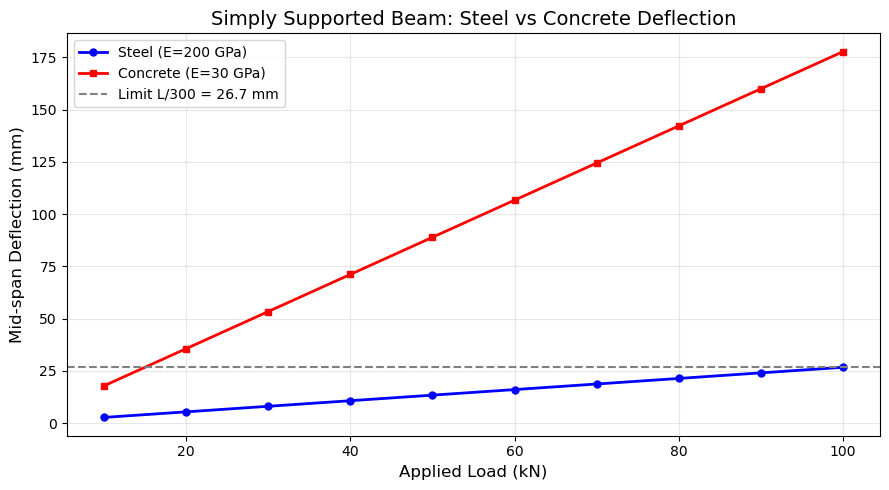


🎉 Congratulations! Your environment is fully configured and working.
You are ready for the upcoming ML for CEE course labs!


In [1]:
# === Final Comprehensive Test ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate beam deflection comparison data
L = 8.0   # span [m]
E_steel = 200e9
E_concrete = 30e9
I = 2.0e-4  # moment of inertia [m⁴]

loads = np.arange(10, 110, 10) * 1e3   # 10 kN to 100 kN

defl_steel = loads * L**3 / (48 * E_steel * I) * 1000      # [mm]
defl_concrete = loads * L**3 / (48 * E_concrete * I) * 1000 # [mm]

# DataFrame
df = pd.DataFrame({
    'Load (kN)': loads / 1e3,
    'Steel Defl. (mm)': np.round(defl_steel, 3),
    'Concrete Defl. (mm)': np.round(defl_concrete, 3)
})
print(df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loads/1e3, defl_steel, 'b-o', markersize=5, linewidth=2, label='Steel (E=200 GPa)')
ax.plot(loads/1e3, defl_concrete, 'r-s', markersize=5, linewidth=2, label='Concrete (E=30 GPa)')
ax.axhline(y=L*1000/300, color='gray', linestyle='--', linewidth=1.5, label=f'Limit L/300 = {L*1000/300:.1f} mm')
ax.set_xlabel('Applied Load (kN)', fontsize=12)
ax.set_ylabel('Mid-span Deflection (mm)', fontsize=12)
ax.set_title('Simply Supported Beam: Steel vs Concrete Deflection', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print('\n🎉 Congratulations! Your environment is fully configured and working.')
print('You are ready for the upcoming ML for CEE course labs!')

---

## 📌 Submission Instructions

1. Complete all `[EXERCISE]` cells by filling in the blanks.
2. Answer the reflection questions in Part 1.7.
3. Run all cells from top to bottom (**Restart Kernel and Run All**) to verify no errors.
4. Save (`Ctrl+S`) and submit the `.ipynb` file via e-campus.

> **Filename: 20241234_홍길동.iynb**

---

## 🧹 Cleanup (Optional)

After the lab, you may remove the practice environments to save disk space.  
**Keep `env_full`** (or rename it to `ml_cee`) for future use. Remove the others:

```bash
conda remove -n env_minimal --all -y
conda remove -n env_viz --all -y
```

---

**Great work! 🎉**  
Questions? Email: seungsab@sejong.ac.kr